# Generate sample reconstructions for a selected sweep model

This notebook shows how to load a trained sweep model and generate sample reconstructions from it. The reconstructions are generated by sampling from the latent space of the model and then decoding those samples back into image space.

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt
import pytorch_lightning as pl

# Ensure repository imports resolve when running notebook from results/...
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != "morphseq" and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.core.run.run_utils import load_trained_model

/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===== User selections =====
DATA_ROOT = Path("/net/trapnell/vol1/home/nlammers/projects/data/morphseq/training_data/models")
SWEEP_NAME = "sweep10"
SELECTED_RUN = None  # set to a full run folder name to force a specific run
RUN_INDEX = -1       # if SELECTED_RUN is None, pick this index from sorted runs
N_SAMPLES = 24
RANDOM_SEED = 42
BATCH_SIZE = N_SAMPLES

# Discover candidate runs
training_outputs = DATA_ROOT / "training_outputs"
candidate_runs = sorted([p for p in training_outputs.glob(f"{SWEEP_NAME}_*") if p.is_dir()])
assert len(candidate_runs) > 0, f"No runs found for pattern: {SWEEP_NAME}_*"

if SELECTED_RUN is not None:
    mdl_path = training_outputs / SELECTED_RUN
    assert mdl_path.exists(), f"Selected run does not exist: {mdl_path}"
else:
    mdl_path = candidate_runs[RUN_INDEX]

sub_runs = sorted([p for p in mdl_path.glob("*") if p.is_dir()])
run_path = sub_runs[0]

print(f"Using run: {run_path}")

Using run: /net/trapnell/vol1/home/nlammers/projects/data/morphseq/training_data/models/training_outputs/sweep10_pips_med_20250727_174249/0


In [3]:
# ===== Load model (all legacy fixups handled inside load_trained_model) =====
lit_model, eval_data_config, model_config = load_trained_model(run_path)
print("Model loaded and frozen.")

Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Loading model from: /net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/lpips/weights/v0.1/squeeze.pth


/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
Model loaded and frozen.


/tmp/8909280.1.trapnell-short.q/ipykernel_3734766/591032255.py:2: UserWarning: load_trained_model: skipped 72 state_dict keys with shape mismatches or renames (e.g. ['loss_fn.D.scales.0.layers.0.0.weight', 'loss_fn.D.scales.0.layers.0.0.bias', 'loss_fn.D.scales.0.layers.1.0.weight'])
  lit_model, eval_data_config, model_config = load_trained_model(run_path)


In [4]:
# ===== Sample test images and run prediction =====
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

dataset = eval_data_config.create_dataset()
test_indices = np.asarray(eval_data_config.test_indices)
sampled = np.random.permutation(test_indices)[:N_SAMPLES]
sampler = SubsetRandomSampler(sampled)

dl = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    num_workers=eval_data_config.num_workers,
    sampler=sampler,
    shuffle=False,
)

trainer = pl.Trainer(accelerator="auto", devices=1, limit_predict_batches=1)
lit_model.current_mode = "test"
preds = trainer.predict(lit_model, dataloaders=dl)

assert len(preds) > 0, "No predictions returned."
batch_pred = preds[0]
orig = batch_pred["orig"].detach().cpu()
recon = batch_pred["recon"].detach().cpu()
snip_ids = batch_pred["snip_ids"]
recon_loss = batch_pred["recon_loss"].detach().cpu().numpy()

print(f"Predicted {orig.shape[0]} samples.")

/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(limit_predict_batches=1)` was configured so 1 batch will be used.
/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker proc

Predicting DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

RuntimeError: shape '[-1, 64, 3, 49, 49]' is invalid for input of size 9507960

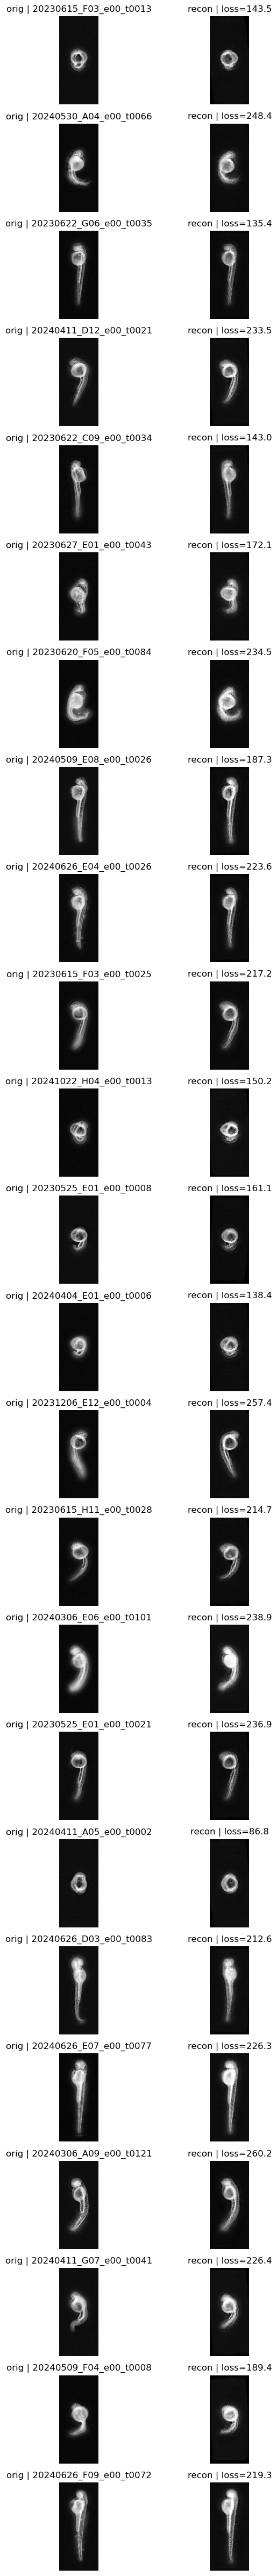

In [7]:
# ===== Display originals and reconstructions in a single figure =====
n_show = orig.shape[0]
fig, axes = plt.subplots(n_show, 2, figsize=(8, max(2*n_show, 6)), squeeze=False)

for i in range(n_show):
    x = orig[i].squeeze().numpy()
    y = recon[i].squeeze().numpy()
    name = Path(snip_ids[i]).stem

    axes[i, 0].imshow(x, cmap="gray")
    axes[i, 0].set_title(f"orig | {name}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y, cmap="gray")
    axes[i, 1].set_title(f"recon | loss={recon_loss[i]:.1f}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()